# Group 14 A4 Formative Task

## Project Title
Green Space Distribution Equity in Greater Melbourne

## Research Question
How evenly is open space distributed across SA2 areas in Greater Melbourne?

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

In [3]:
sa2 = gpd.read_file(
    "boundary/study_area.gpkg",
)

open_space = gpd.read_file(
    "open_space/open_space_melbourne.gpkg"
)

print(sa2.shape)
print(open_space.shape)
sa2.head()

(360, 18)
(38639, 22)


,id,SA2_CODE_2021,SA2_NAME_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,GCCSA_NAME_2021,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.0114,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.6654 -37.8701, 144.66529 -..."
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,114.0332,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.73479 -37.94361, 144.73479..."
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.7569,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.64116 -37.88193, 144.64109..."
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,127.6631,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.59729 -37.94211, 144.59733..."
4,1088,213051579,Manor Lakes - Quandong,1,New,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,72.0339,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.51648 -37.87412, 144.54997..."


360


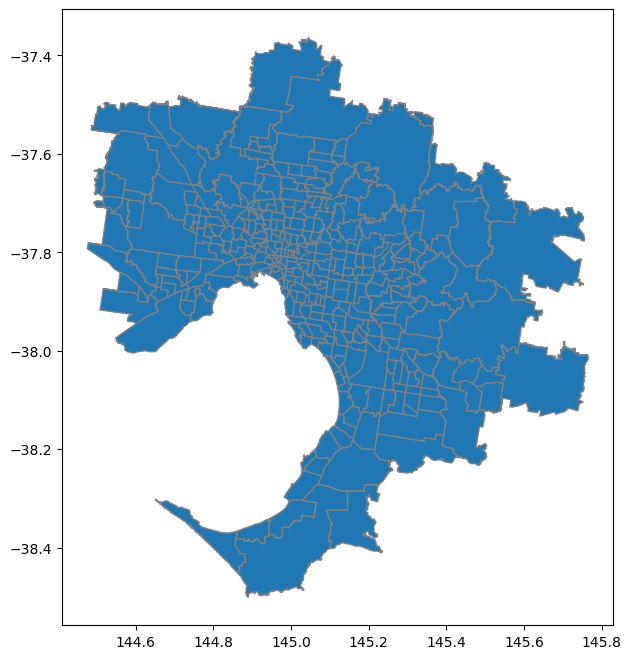

In [4]:
melb = sa2.copy()

print(len(melb))

melb.plot(
    figsize=(8,8),
    edgecolor="grey"
)

plt.show()

In [5]:
melb=melb.to_crs(7855)
open_space=open_space.to_crs(7855)

melb["sa2_area"]=melb.geometry.area

overlay=gpd.overlay(
    open_space,
    melb[
        [
            "SA2_CODE_2021",
            "geometry"
        ]
    ],
    how="intersection"
)

overlay["open_area"]=overlay.area

summary=(
    overlay
    .groupby(
        "SA2_CODE_2021"
    )
    ["open_area"]
    .sum()
    .reset_index()
)

melb=melb.merge(
    summary,
    on="SA2_CODE_2021",
    how="left"
)

melb["open_area"]=(
    melb["open_area"]
    .fillna(0)
)

melb["coverage"]=(
    melb["open_area"]
    /
    melb["sa2_area"]
)*100

melb.head()

,id,SA2_CODE_2021,SA2_NAME_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,...,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry,sa2_area,open_area,coverage
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,2,Victoria,AUS,Australia,7.0114,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((294653.085 5806028.552, 294645...",7.012411e+06,8.268239e+05,11.790865
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,2,Victoria,AUS,Australia,114.0332,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((300955.332 5798020.917, 300955...",1.140616e+08,7.032759e+07,61.657575
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,2,Victoria,AUS,Australia,7.7569,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((292554.398 5804662.406, 292548...",7.758551e+06,1.657223e+06,21.359952
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,2,Victoria,AUS,Australia,127.6631,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((288867.598 5797885.557, 288870...",5.991604e+07,2.559582e+07,42.719471
4,1088,213051579,Manor Lakes - Quandong,1,New,21305,Wyndham,213,Melbourne - West,2GMEL,...,2,Victoria,AUS,Australia,72.0339,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((281564.588 5805244.323, 284521...",1.493557e+07,6.630091e+06,44.391269


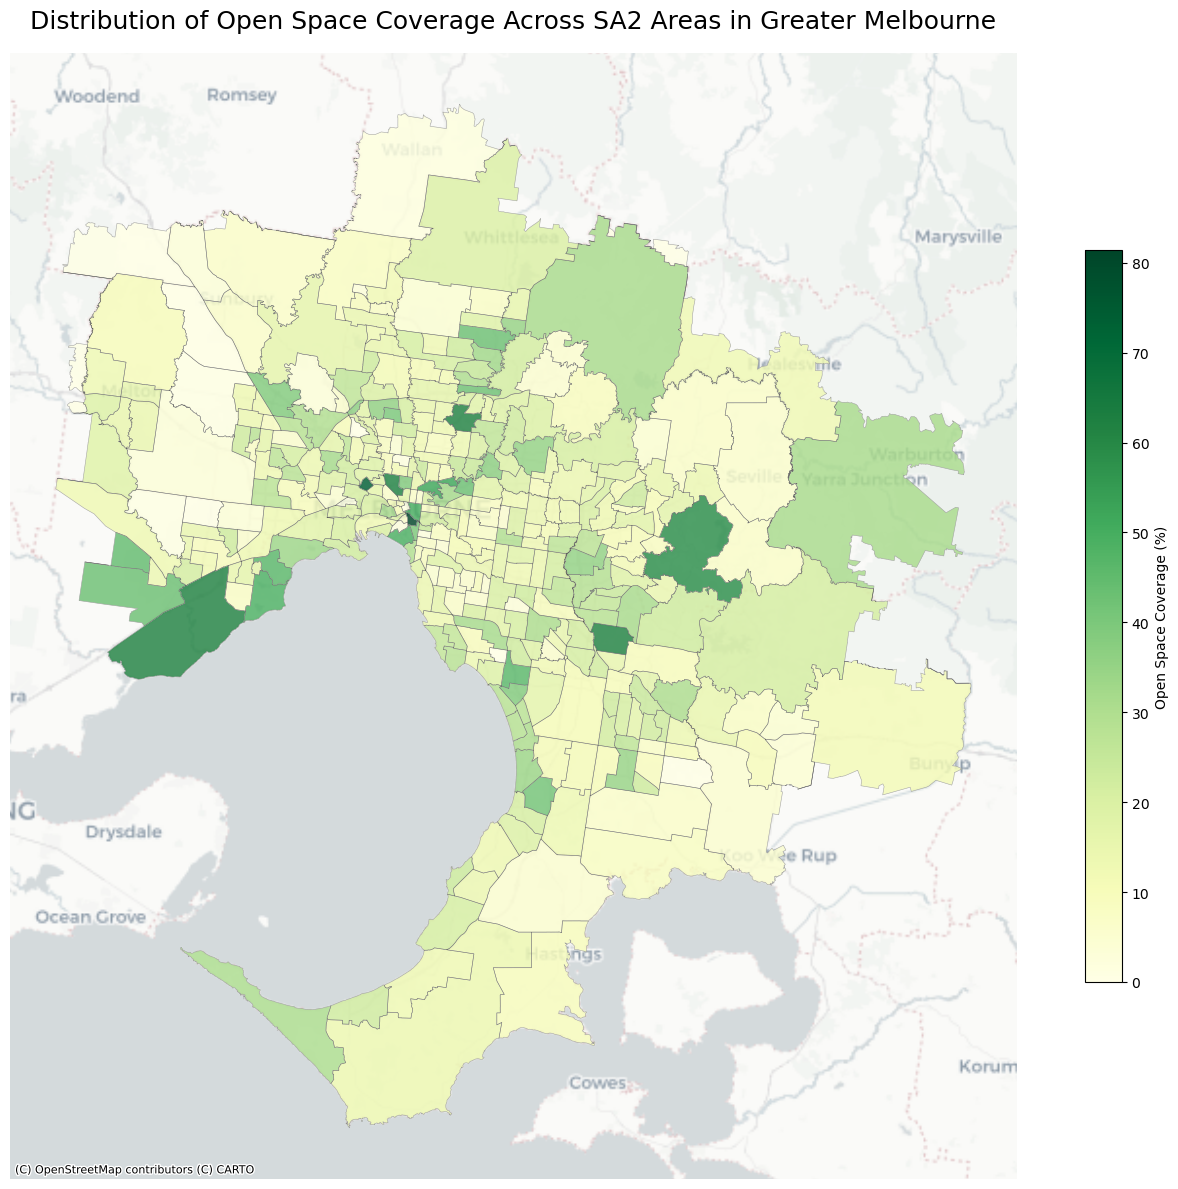

In [6]:
melb=melb.to_crs(3857)

fig,ax=plt.subplots(
    figsize=(14,12)
)

melb.plot(
    column="coverage",
    cmap="YlGn",
    linewidth=0.35,
    edgecolor="white",
    alpha=0.82,
    legend=True,
    ax=ax,
    legend_kwds={
        "label":"Open Space Coverage (%)",
        "shrink":0.65
    }
)

melb.boundary.plot(
    ax=ax,
    linewidth=0.4,
    color="black",
    alpha=0.35
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title(
    "Distribution of Open Space Coverage Across SA2 Areas in Greater Melbourne",
    fontsize=18,
    pad=18
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    "green_space_formative.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation

This map presents the spatial distribution of open space coverage across SA2 areas in Greater Melbourne. The results indicate substantial variation in the proportion of land allocated to open space throughout the metropolitan region.

Higher open space coverage appears in several outer metropolitan and peripheral areas, while many inner and middle-ring suburbs display lower proportions. This pattern may be associated with differences in development intensity, land use allocation, and the availability of large public reserves.

In relation to the research question, the findings suggest that green space is not evenly distributed across Greater Melbourne. Although this map focuses only on spatial coverage, it provides an initial indication of potential inequality in environmental amenity and accessibility. Future analysis may incorporate population data to evaluate green space per capita and better assess distribution equity.

## Declaration

I acknowledge the use of ChatGpt to help me debug my code for data analysis and generate images for this assessment.

I used it to help visualise the distribution of green space in the Melbourne metropolitan area.

A full record of prompts and outputs is available upon request.

## Research Question 2

How do urban green infrastructure characteristics (such as open space and tree density) influence spatial patterns of urban heat intensity in Greater Melbourne?

### 1. Introduction
Urban heat is one of the most significant environmental challenges facing contemporary cities. Green infrastructure, particularly public open space and tree density, have been widely recognised as an effective strategy for mitigating urban heat. This analysis investigates the relationship between open space coverage and urban heat intensity across Greater Melbourne using spatial analytical techniques.

### 2. ESDA

In [12]:
import geopandas as gpd
import pandas as pd

heat = gpd.read_file("urban_heat/urban_heat.gpkg")
heat_sa2 = (heat.groupby("SA2_NAME16")["UHI18_M"].mean().reset_index())
trees = gpd.read_file("urban_tree_point.gpkg")

# Merge UHI to melb
q2 = melb.merge(
    heat_sa2,
    left_on="SA2_NAME_2021",
    right_on="SA2_NAME16",
    how="inner"
)

In [13]:
trees_7855 = trees.to_crs(epsg=7855)
q2_7855 = q2.to_crs(epsg=7855)

In [14]:
# Spatial join
# Count trees within each SA2 region
tree_sa2 = gpd.sjoin(
    trees_7855,
    q2_7855,
    how="inner",
    predicate="within"
)

# Aggregate tree counts by SA2 code
tree_count = tree_sa2.groupby("SA2_CODE_2021").size().reset_index(name="tree_count")

# Merge tree counts to q2 and calculate density
q2 = q2.merge(tree_count, on="SA2_CODE_2021", how="left")
q2["tree_count"] = q2["tree_count"].fillna(0)

# Calculate tree density (per square kilometer)
q2["tree_density"] = q2["tree_count"] / (q2["sa2_area"] / 1e6)

q2.head()

,id,SA2_CODE_2021,SA2_NAME_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,...,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry,sa2_area,open_area,coverage,SA2_NAME16,UHI18_M,tree_count,tree_density
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,7.0114,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((16104078.525 -4561091.453, 161...",7.012411e+06,8.268239e+05,11.790865,Hoppers Crossing - South,8.385504,21388.0,3050.020758
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,114.0332,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((16111802.697 -4571463.547, 161...",1.140616e+08,7.032759e+07,61.657575,Werribee - South,6.900058,52109.0,456.849792
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,7.7569,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((16101380.797 -4562759.439, 161...",7.758551e+06,1.657223e+06,21.359952,Werribee - East,7.630220,24115.0,3108.183493
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,127.6631,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((16096496.805 -4571250.532, 160...",5.991604e+07,2.559582e+07,42.719471,Werribee - West,8.069294,24639.0,411.225408
4,1112,214021383,Point Nepean,0,No change,21402,Mornington Peninsula,214,Mornington Peninsula,2GMEL,...,67.1876,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((16125943.474 -4643363.334, 161...",6.719391e+07,2.059349e+07,30.647845,Point Nepean,3.073223,49387.0,734.992220


In [15]:
# Export Q2 result
q2_export = q2[
    [
        "SA2_CODE_2021",
        "SA2_NAME_2021",
        "coverage",
        "open_area",
        "UHI18_M",
        "tree_density",
        "geometry"
    ]
].copy()

q2_export["SA2_CODE_2021"] = q2_export["SA2_CODE_2021"].astype(str)

q2_export = q2_export.rename(
    columns={
        "SA2_CODE_2021": "sa2_code",
        "SA2_NAME_2021": "sa2_name"
    }
)

q2_export.to_file("q2_green_heat.gpkg", driver="GPKG")

#### 2.1 Summary Statistics 

In [17]:
q2[["tree_count", "tree_density", "coverage", "UHI18_M"]].describe()

,tree_count,tree_density,coverage,UHI18_M
count,257.000000,257.000000,257.000000,257.000000
mean,27934.595331,2664.328122,18.383258,8.266447
std,27558.029601,1229.724051,12.299425,1.828274
min,0.000000,0.000000,0.000000,0.029429
25%,12021.000000,1843.198563,10.025083,7.517670
50%,20545.000000,2770.123184,16.070639,8.398132
75%,30817.000000,3644.043012,22.591331,9.373265
max,175247.000000,5041.707885,74.079449,11.716022


From the output, we can see that the average number of trees in each SA2 area of ​​Melbourne is approximately 27,935, with an average tree density of 2,664 trees per square kilometer. Extreme values ​​were observed: some SA2 areas had zero trees and a density of zero, while the ecologically best-preserved areas had a total of 175,247 trees and a density of 5,041 trees per square kilometer, indicating an extremely uneven distribution of green canopy resources throughout the city.

We can also see that the distribution of green space in Melbourne is severely polarized, with over 75% of suburbs having a green coverage rate of less than 22.59%, and only a very few marginal eco-zones possessing exceptionally high green coverage. The urban heat island effect is a systemic crisis, with over 75% of the area experiencing an average temperature range exceeding 7.52°C, meaning the vast majority of residents face extremely high heat exposure risks during the summer.

#### 2.2 Tree Density Histogram 

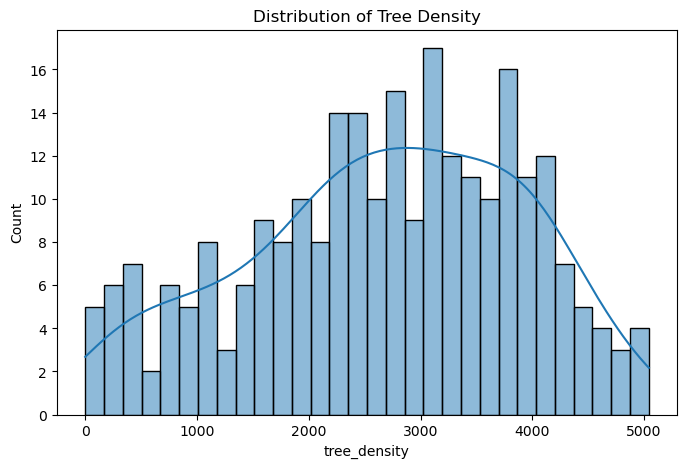

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    q2["tree_density"],
    bins=30,
    kde=True
)

plt.title("Distribution of Tree Density")

plt.show()

The histogram shows that the tree density in the SA2 areas of Melbourne follows an approximately normal distribution, with the data mainly concentrated between 2,000 and 4,000 trees per square kilometer, indicating that most areas have a medium to high level of green coverage.

#### 2.3 Open Space Coverage Histogram 

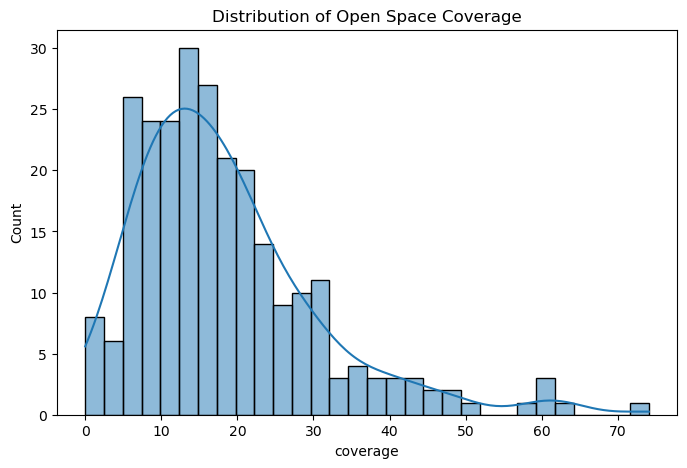

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    q2["coverage"],
    bins=30,
    kde=True
)

plt.title("Distribution of Open Space Coverage")

plt.show()

The histogram of open space coverage reveals a highly right-skewed (positively skewed) distribution across the SA2 statistical units in Greater Melbourne.

The vast majority of suburban areas have relatively low green cover, specifically between 5% and 20%. The peak distribution occurs around 12% to 15%, indicating that green infrastructure in most Melbourne suburbs is generally poor. The distribution curve exhibits a long right tail, with coverage reaching over 70%. These extreme values ​​represent a few exceptional low-density fringe suburbs, or areas close to major protected areas and national parks, such as the Yarra Range or Dandenong Mountain.

#### 2.4 Urban Heat Histogram

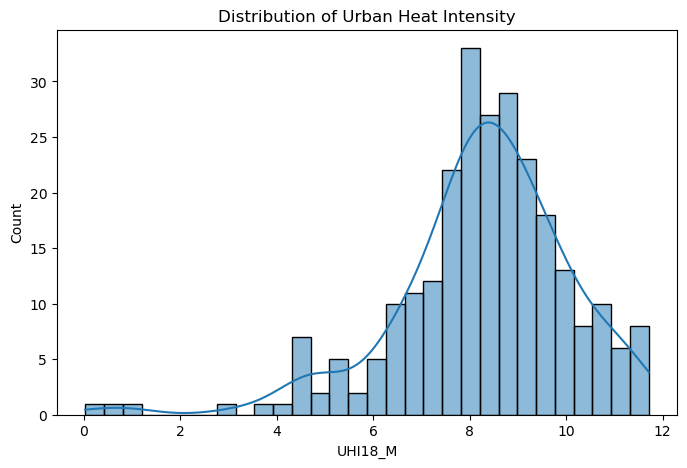

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    q2["UHI18_M"],
    bins=30,
    kde=True
)

plt.title("Distribution of Urban Heat Intensity")

plt.show()

The histogram for Urban Heat Island Intensity (UHI18_M) displays a distinct left-skewed (negatively skewed) distribution, which stands in sharp contrast to the green space distribution.

The data are primarily concentrated in the high-intensity range, with major peaks between 7.5°C and 9.5°C. This indicates that during the summer peak season, heat accumulation and urban warming are systemic and pervasive environmental pressures affecting most SA2 residential units in Melbourne.

A relatively flat, low-frequency distribution appears in the low-value areas below 5°C, approaching 0°C. These low-heat island intensity areas spatially correspond highly to the high-green-coverage polygons in the previous figure, representing "cool island" buffer zones within the city, demonstrating the effective blocking and absorption of solar radiation by the natural canopy.

The inverse skewness between open space coverage figure and urban heat figure visually validates the team's hypothesis: areas with severe deficiencies in green space infrastructure correspond to the dominant high-temperature disaster clusters in the statistical charts.

#### 2.5 Pivot Table

In [29]:
# Top 10 Hottest SA2
pivot_heat = q2[["SA2_NAME_2021", "UHI18_M"]].sort_values("UHI18_M", ascending=False).head(10)
pivot_heat

,SA2_NAME_2021,UHI18_M
43,Burnside Heights,11.716022
208,Cranbourne,11.665816
40,Sydenham,11.574009
100,Cairnlea,11.566726
245,Narre Warren - North East,11.466223
7,Melton West,11.451552
37,Delahey,11.409298
111,Burnside,11.348166
124,Moorabbin Airport,11.302094
28,Essendon Airport,11.219677


The 10 hottest areas in Melbourne are highly concentrated in the west, such as Burnside Heights, Sydenham, Cairnlea, Melton West, and Delahey, as well as the southeast, such as Cranbourne and Narre Warren. These areas are under extreme pressure from the urban heat island. Many of the western areas on the list are rapidly developing, peripheral suburbs with relatively low incomes for their residents, providing direct evidence for Question 3 to further explore whether vulnerable groups are suffering the adverse effects of extreme microclimates.

In [31]:
# Divide the coverage into 5 groups
q2["tree_density_group"] = pd.qcut(q2["tree_density"], 5, labels=["Low", "medium_low", "Medium", "medium_high", "High"])
# Calculate the average heat island effect for each group
pivot = pd.pivot_table(q2, values="UHI18_M", index="tree_density_group", aggfunc="mean")
pivot

,UHI18_M
tree_density_group,
Low,7.676172
medium_low,8.951472
Medium,8.614757
medium_high,8.369604
High,7.742087


Across all tree density groups from low to high, the average heat island intensity remained at a relatively high level, fluctuating approximately from 7.67°C to 8.95°C, exhibiting non-linear fluctuations rather than a monotonous linear decline.

In [33]:
# Divide the coverage into 5 groups
q2["coverage_group"] = pd.qcut(q2["coverage"], 5, labels=["Low", "medium_low", "Medium", "medium_high", "High"])
# Calculate the average heat island effect for each group
pivot = pd.pivot_table(q2, values="UHI18_M", index="coverage_group", aggfunc="mean")
pivot

,UHI18_M
coverage_group,
Low,8.209160
medium_low,8.249160
Medium,8.365996
medium_high,8.143713
High,8.363429


Surprisingly, across all groups from low to high green coverage, the average heat island intensity remained at a relatively high level, ranging from approximately 8.14°C to 8.37°C, exhibiting a slight non-linear fluctuation rather than a simple linear decline. 

This suggests that the heat island effect in Greater Melbourne is a large-scale, regional climate phenomenon. While highly green areas can still provide shade and comfort for pedestrians, the table highlights the systemic nature of Melbourne's heatwave crisis. Simply adding green space in isolation in a suburb cannot completely eliminate the regional heat accumulation. This necessitates that future urban planning establish a networked green infrastructure, rather than scattered, isolated parks.

#### 2.6 Map

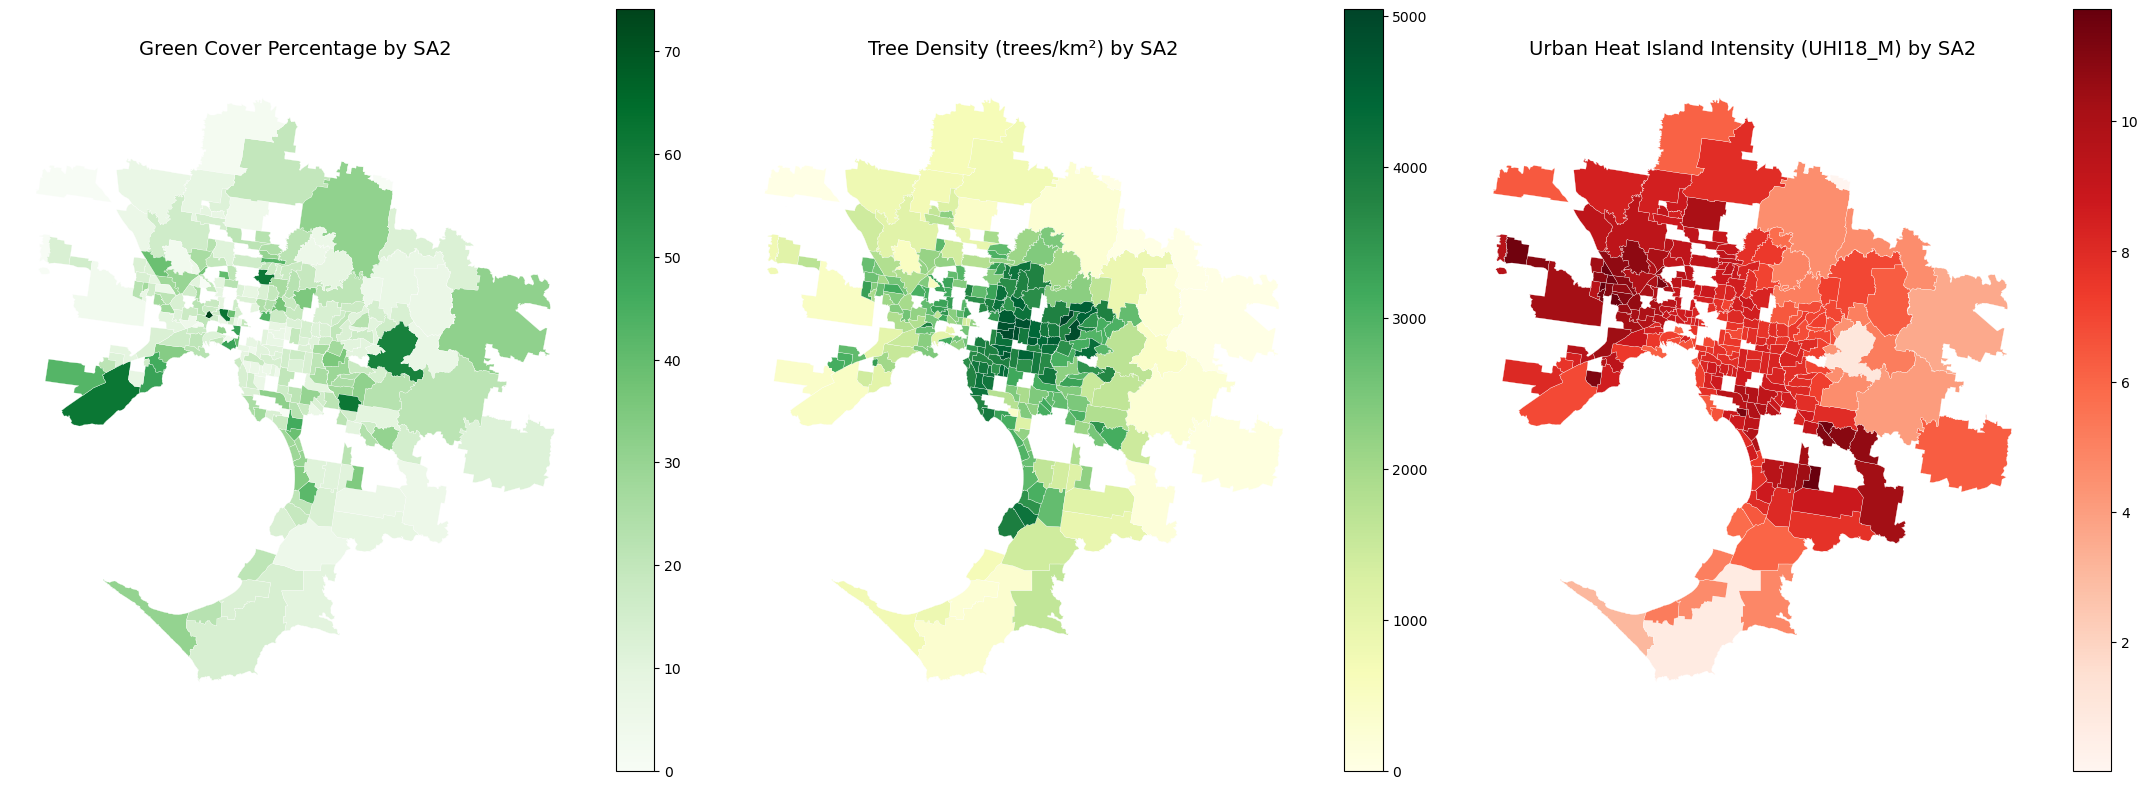

In [36]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 8))

# Green Cover Percentage
q2.plot(column='coverage', cmap='Greens', legend=True, ax=ax1, edgecolor='white', linewidth=0.2)
ax1.set_title('Green Cover Percentage by SA2', fontsize=14, pad=10)
ax1.set_axis_off()

# Tree Density
q2.plot(column='tree_density', cmap='YlGn', legend=True, ax=ax2, edgecolor='white', linewidth=0.2)
ax2.set_title('Tree Density (trees/km²) by SA2', fontsize=14, pad=10)
ax2.set_axis_off()

# Urban Heat Island Intensity
q2.plot(column='UHI18_M', cmap='Reds', legend=True, ax=ax3, edgecolor='white', linewidth=0.2)
ax3.set_title('Urban Heat Island Intensity (UHI18_M) by SA2', fontsize=14, pad=10)
ax3.set_axis_off()

plt.tight_layout()
plt.show()

The green cover percentage map on the left and the tree density map in the middle show a high degree of synergy in spatial distribution. High-density urban forests (dark green areas) are not only widely distributed in ecological reserves in the northeast (such as the Yarra Valley), but also exhibit extremely high tree density in residential areas extending eastward from the city center (reaching over 4000 $trees/km²$). Conversely, Melbourne's western industrial areas and northern edges suffer from a double shortage of green resources—low coverage and low density—with tree densities generally below 1000 $trees/km²$.

The tree density map in the middle and the heat island intensity map on the right are geographically inverted. The deep red core area, where the heat island effect is most severe and temperatures are abnormally high by 8 °C to 10°C, almost completely covers the western and northwestern areas shown in white (tree density close to 0) in the middle map. This indicates that the lack of tree shade and insufficient transpiration are the core geographical reasons why western and northern suburbs have become areas severely affected by extreme weather.

Therefore, mitigating the urban heat island effect depends not only on increasing green space but also, and perhaps more importantly, on the planting density of trees per unit area of ​​land.

### 3. Green Space Coverage, Tree Density and Urban Heat Correlation Analysis

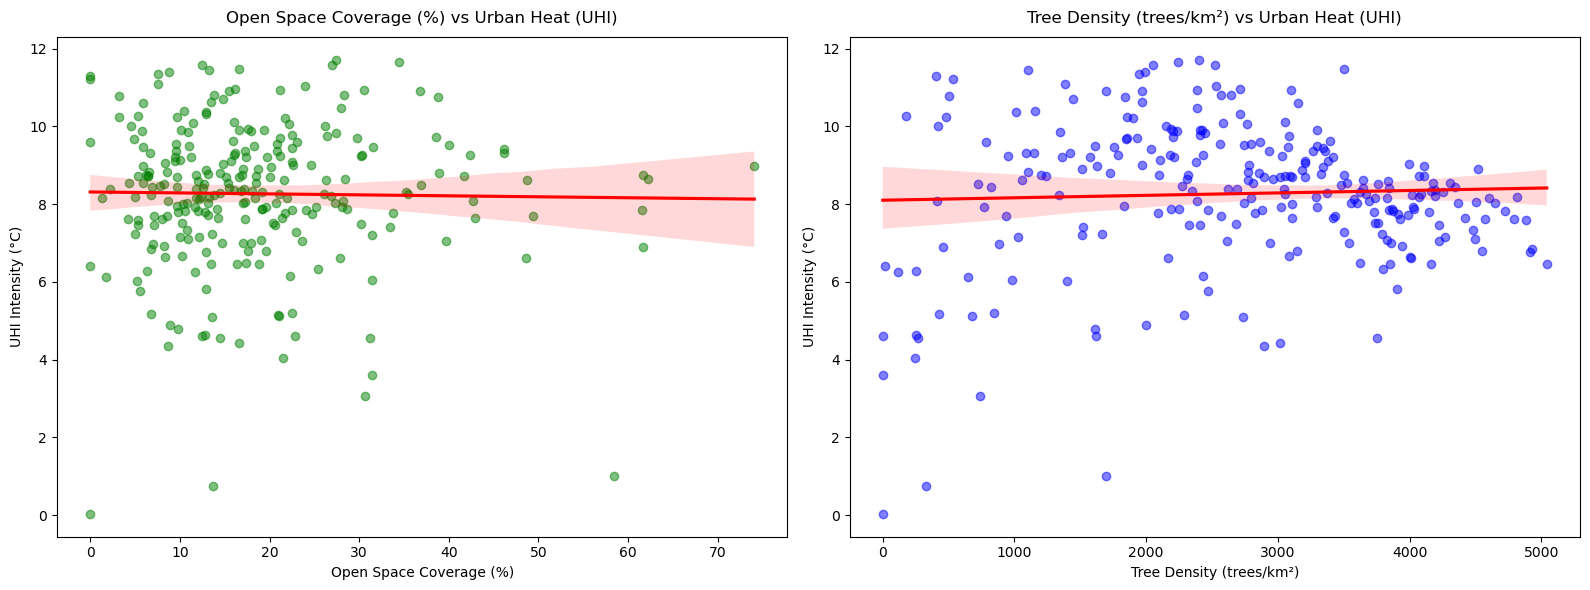

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Green Space Coverage vs UHI
sns.regplot(
    x="coverage",
    y="UHI18_M",
    data=q2,
    ax=ax1,
    scatter_kws={'alpha':0.5, 'color':'green'}, 
    line_kws={'color':'red'}                
)
ax1.set_title("Open Space Coverage (%) vs Urban Heat (UHI)", fontsize=12, pad=10)
ax1.set_xlabel("Open Space Coverage (%)")
ax1.set_ylabel("UHI Intensity (°C)")

# Tree Density vs UHI
sns.regplot(
    x="tree_density",
    y="UHI18_M",
    data=q2,
    ax=ax2,
    scatter_kws={'alpha':0.5, 'color':'blue'},
    line_kws={'color':'red'}
)
ax2.set_title("Tree Density (trees/km²) vs Urban Heat (UHI)", fontsize=12, pad=10)
ax2.set_xlabel("Tree Density (trees/km²)")
ax2.set_ylabel("UHI Intensity (°C)")

plt.tight_layout()
plt.show()

The regression trend line between open space coverage and urban heat island intensity (UHI18_M) exhibits a nearly horizontal slope. This indicates that the direct linear correlation between the two is extremely weak at the global level across all SA2 statistical units in Melbourne. As green coverage exceeds 40%, the confidence interval (shaded area) on the right side of the chart widens significantly, meaning that within high green coverage areas, the dispersion and statistical uncertainty of data points increase substantially. In the densely populated 5% to 30% coverage range, even with slight increases in green coverage in some areas, the overall average heat island intensity remains high because it fails to reach the critical threshold for fundamentally altering the local thermal balance.

The right graph shows that when the tree density is between 0 and 2500 trees, the temperature continuously rises, forming a high-temperature core area. However, once the tree density crosses the critical point of 3000 to 3500 $trees/km²$, the maximum heat island intensity in all areas exceeding this threshold is below 9°C, and the scattered points in the high-density areas generally slope downstream. This demonstrates that a certain cluster size of micro-tree density is necessary to effectively suppress extreme heat.

These weak linear trends do not mean that green spaces have no cooling effect; this is because the heat island effect in Greater Melbourne is a large-scale, regional, and complex atmospheric phenomenon. Large areas of hardened, impermeable surfaces, such as dense industrial buildings, form a massive heat-absorbing dome. During periods of extreme summer temperatures, this systemic accumulation of heat across regions often partially masks the localised cooling effect of isolated parks within a single SA2 area.

### 4. Moran's I
#### 4.1 Global Moran's I

In [42]:
from libpysal.weights import Queen
from esda.moran import Moran

w = Queen.from_dataframe(q2, use_index=False)

w.transform = "r"

moran_uhi = Moran(q2["UHI18_M"], w)

print(f"Moran's I:  {moran_uhi.I:.4f}")
print(f"P-value:    {moran_uhi.p_sim:.4f}")

Moran's I:  0.7530
P-value:    0.0010


Global Moran's I measures the spatial clustering of a single variable across the entire study area. An index close to 1 indicates a high degree of clustering of similar values, and the significance ($p < 0.05$) confirms that this clustering is a definite fact, not a random coincidence.

The Global Moran's I calculated for the urban heat island intensity (UHI18_M) is as high as $I = 0.7530$, and the significance value $p = 0.001$ is less than 0.05, rejecting the null hypothesis. This refutes the assumption of spatial random distribution and strongly demonstrates that the thermal environment of the Greater Melbourne area exhibits extremely strong positive spatial autocorrelation and geographical clustering characteristics.

#### 4.2 Bivariate Moran's I

Bivariate Moran's I is used to measure the spatial correlation between two different variables, assessing whether a local observation of one variable is significantly influenced by another variable in its surrounding neighborhood.

* Green Space Coverage

In [45]:
from esda.moran import Moran_BV

mbv_coverage = Moran_BV(q2["coverage"], q2["UHI18_M"], w)

print(f"Moran's I:  {mbv_coverage.I:.4f}")
print(f"P-value:    {mbv_coverage.p_sim:.4f}")

Moran's I:  0.0534
P-value:    0.0580


When conducting a cross-spatial association analysis between local green space coverage and the surrounding urban heat island (UHI) intensity, the Bivariate Moran's I appears to be extremely weak, and the $p$-value failed the significance test at 0.05. This insignificant result is precisely because Melbourne's high temperatures are overwhelmingly concentrated over large areas globally (with a Global Moran's I of 0.7530), meaning that during the hottest periods, the local cooling effect of green space in a single SA2 suburb is directly weakened by the hot winds released from the surrounding surface.

* Tree Density

In [47]:
mbv_density = Moran_BV(q2["tree_density"], q2["UHI18_M"], w)

print(f"Moran's I:  {mbv_density.I:.4f}")
print(f"P-value:    {mbv_density.p_sim:.4f}")

Moran's I:  0.0415
P-value:    0.2350


The Bivariate Moran's test showed that the spatial cross-correlation between tree density and the urban heat island effect in Melbourne was not statistically significant (Moran's I = 0.0415, p = 0.2150), indicating that the cooling effect of trees has a strong local limitation. Trees mainly cool the local area by directly shading the ground and through local transpiration. Once they cross relatively macro-level administrative boundaries like SA2, their cooling effect becomes ineffective. Therefore, even if the trees in a neighboring area are dense, they contribute almost nothing to the heat island effect of that area.

### 5. SA2-Level Land Cover Fractions from Raster Data

This section uses the 25m resolution Victorian Land Cover Time Series raster to derive SA2-level fractions of key land cover types via zonal statistics.

The following composite variables are created:
- tree_total_frac: sum of scattered trees (code 5), treed native (12), and urban vegetation (6)
- grass_total_frac: sum of native grassland (7) and exotic pasture/grass (8)
- built_frac: built environment (code 4)
- water_frac: water bodies (code 1)
- bare_frac: sum of native bare ground (2) and non‑native bare ground (3)

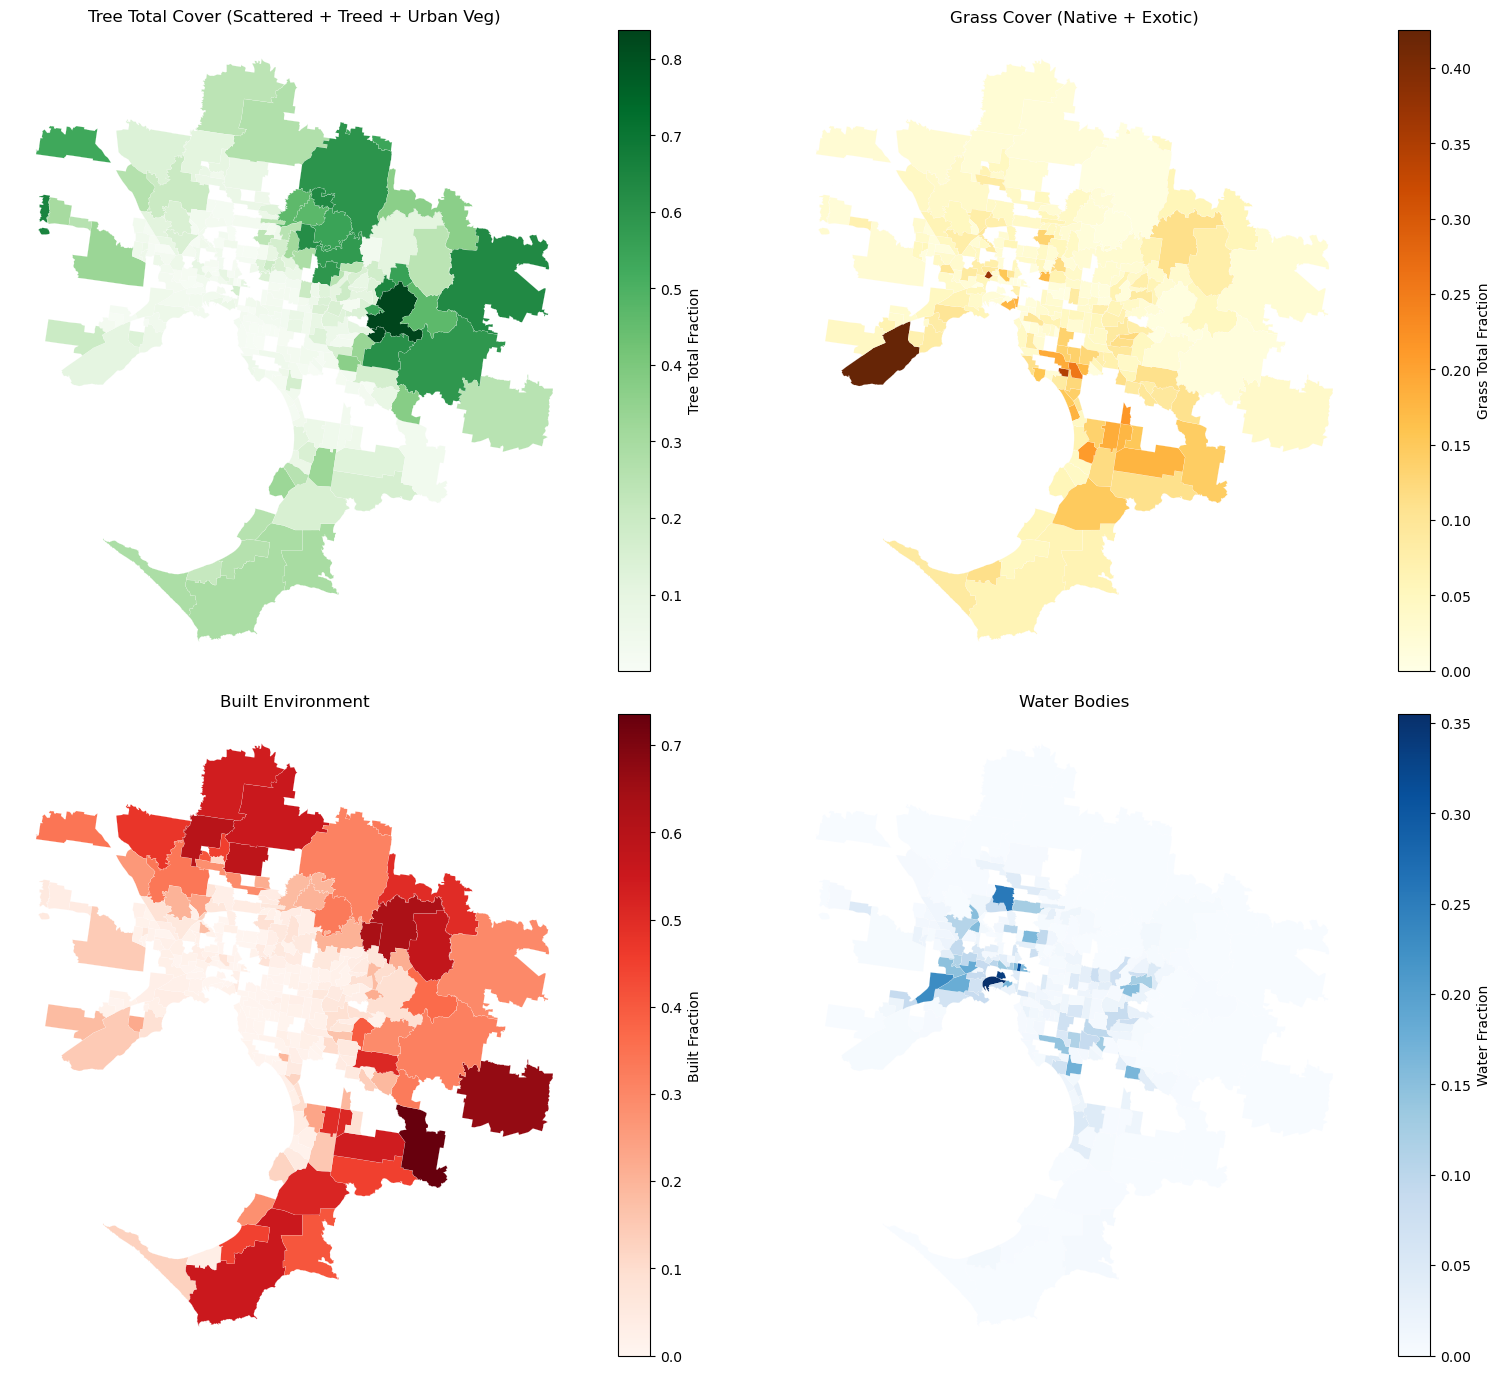

In [51]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from rasterstats import zonal_stats

# Read landcover.tif raster and perform zonal statistics
q2_projected = q2.to_crs(epsg=3857)

raster_path = 'landcover.tif'

zonal_results = zonal_stats(q2_projected, raster_path, categorical=True)

# Calculate core variable fractions from zonal_results
# Define class codes
codes = {
    'water': 1,
    'scattered_trees': 5,
    'urban_veg': 6,
    'grass_native': 7,
    'grass_exotic': 8,
    'treed_native': 12,
    'built': 4,
    'bare_native': 2,
    'bare_not_native': 3
}

# Initialise fraction lists
tree_total_frac = []
grass_total_frac = []
built_frac = []
water_frac = []
bare_frac = []

for zone in zonal_results:
    total = sum(zone.values())
    if total == 0:
        tree_total_frac.append(0)
        grass_total_frac.append(0)
        built_frac.append(0)
        water_frac.append(0)
        bare_frac.append(0)
        continue
    
    # Total tree fraction = scattered trees + treed native + urban vegetation
    tree = (zone.get(codes['scattered_trees'], 0) +
            zone.get(codes['treed_native'], 0) +
            zone.get(codes['urban_veg'], 0))
    
    # Total grass fraction = native grass + exotic grass
    grass = (zone.get(codes['grass_native'], 0) +
             zone.get(codes['grass_exotic'], 0))
    
    # Built environment
    built = zone.get(codes['built'], 0)
    
    # Water bodies
    water = zone.get(codes['water'], 0)
    
    # Bare soil = native bare + non-native bare
    bare = (zone.get(codes['bare_native'], 0) +
            zone.get(codes['bare_not_native'], 0))
    
    tree_total_frac.append(tree / total)
    grass_total_frac.append(grass / total)
    built_frac.append(built / total)
    water_frac.append(water / total)
    bare_frac.append(bare / total)

# Add to GeoDataFrame
q2_projected['tree_total_frac'] = tree_total_frac
q2_projected['grass_total_frac'] = grass_total_frac
q2_projected['built_frac'] = built_frac
q2_projected['water_frac'] = water_frac
q2_projected['bare_frac'] = bare_frac

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Total tree fraction
q2_projected.plot(column='tree_total_frac', cmap='Greens', legend=True,
                  legend_kwds={'label': 'Tree Total Fraction'},
                  edgecolor='white', linewidth=0.1, ax=axes[0])
axes[0].set_title('Tree Total Cover (Scattered + Treed + Urban Veg)', fontsize=12)
axes[0].axis('off')

# Total grass fraction
q2_projected.plot(column='grass_total_frac', cmap='YlOrBr', legend=True,
                  legend_kwds={'label': 'Grass Total Fraction'},
                  edgecolor='white', linewidth=0.1, ax=axes[1])
axes[1].set_title('Grass Cover (Native + Exotic)', fontsize=12)
axes[1].axis('off')

# Built environment fraction
q2_projected.plot(column='built_frac', cmap='Reds', legend=True,
                  legend_kwds={'label': 'Built Fraction'},
                  edgecolor='white', linewidth=0.1, ax=axes[2])
axes[2].set_title('Built Environment', fontsize=12)
axes[2].axis('off')

# Water fraction
q2_projected.plot(column='water_frac', cmap='Blues', legend=True,
                  legend_kwds={'label': 'Water Fraction'},
                  edgecolor='white', linewidth=0.1, ax=axes[3])
axes[3].set_title('Water Bodies', fontsize=12)
axes[3].axis('off')

plt.tight_layout()
plt.savefig('landcover_4maps.png', dpi=300, bbox_inches='tight')
plt.show()

These four spatial pattern maps reveal the geological environment of the Greater Melbourne area: High built environment values ​​are extremely concentrated in the city center, north and southeast of Melbourne, while tree cover is lower in these areas, which also have a stronger heat island effect.

### 6. Geographically Weighted Regression (GWR) Model

Geographically Weighted Regression (GWR) is a local modeling method that allows regression coefficients to vary with spatial location, and can effectively reveal the spatial nonstationarity of variable relationships.

In [54]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import Queen

from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

import warnings
import sys
import os
import warnings
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# Reproject
q2_projected = q2.to_crs(epsg=3857) 
centroids = q2_projected.geometry.centroid

# Extract x and y coordinates of centroids and stack them into a coordinate matrix
coords = np.column_stack((centroids.x, centroids.y))

# Dependent Variable
y = q2['UHI18_M'].values.reshape((-1, 1))

# Independent Variables
X_variables = q2[['coverage', 'tree_density']].values

# Initialise bandwidth selector
bw_selector = Sel_BW(coords, y, X_variables, kernel='gaussian', fixed=False)
best_bw = bw_selector.search(criterion='AICc')
                             
# GWR Model
gwr_model = GWR(coords, y, X_variables, bw=best_bw, kernel='gaussian', fixed=False)
gwr_results = gwr_model.fit()

gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                 257
Number of covariates:                                                     3

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            854.019
Log-likelihood:                                                    -518.980
AIC:                                                               1043.960
AICc:                                                              1046.119
BIC:                                                               -555.446
R2:                                                                   0.002
Adj. R2:                                                             -0.006

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

#### 6.1 OLS Results

The ordinary least squares (OLS) linear regression model to empirically test the linear hypothesis of $$UHI = \beta_0 + \beta_1 \cdot \text{Open Space Coverage} + \beta_2 \cdot \text{Tree Density}$$ across SA2 spatial units in the Greater Melbourne area.

Based on the output, we can see that the $p$-values ​​for both independent variables are > 0.05 (open space coverage: $p$=0.824, tree density: $p$=0.512), therefore we fail to refuse the null hypothesis, indicating no significant linear relationship.

$R^2 ≈ $ 0.002, and after adjustment, $R^2$ < 0, suggesting that open space coverage and tree density have almost no global linear explanatory power for urban heat island intensity (UHI).

The OLS model concludes that increasing open space or tree density does not linearly reduce heat island intensity across the entire Melbourne region.

#### 6.2 GWR Model

The GWR model is specified as:

$$
\text{UHI}_i = \beta_0(u_i, v_i) + \beta_1(u_i, v_i) \cdot \text{Open Space Coverage}_i + \beta_2(u_i, v_i) \cdot \text{Tree Density}_i + \varepsilon_i
$$

where:

- $(u_i, v_i)$ are the spatial coordinates (e.g., projected easting and northing) of SA2 centroid $i$;
- $\beta_0(u_i, v_i)$ is the local intercept at location $i$;
- $\beta_1(u_i, v_i)$ and $\beta_2(u_i, v_i)$ are local coefficients for open space coverage and tree density, respectively;
- $\varepsilon_i$ is the random error term.

The local coefficients are estimated via weighted least squares using an adaptive Gaussian kernel, with bandwidth selected by minimizing the AICc criterion.

The GWR's $R^2$ = 0.325, adjusted $R^2$ = 0.299, is a significant improvement compared to the global model's 0.002. This indicates that incorporating spatial location into the model significantly enhances its explanatory power.

The AICc decreased from 1046 to 959.6, demonstrating that the GWR model's fit is far superior to ordinary linear regression.

The bandwidth of 47 neighbors indicates that each local regression uses approximately 47 neighboring SA2 regions for weighted fitting, suggesting a moderate scale of influence.

From the parameter statistics table, we can see:

* Intercept (X0): Mean is 9.32, range from 6.78 to 10.75, indicating significant differences in the basic heat island intensity across different regions.

* Open space coverage coefficient (X1): Mean is -0.008, range from -0.024 to 0.012, indicating that in most areas, cover has a slight negative impact on UHI, i.e., cooling, but in some areas it has a positive impact, i.e., anomalous warming. Significant spatial heterogeneity is observed.

* Tree density coefficient (X2): Mean close to 0, range from -0.001 to 0.000, indicating that the effect of tree density is very weak and inconsistent in direction.

In [58]:
# Add to GeoDataFrame
q2['gwr_intercept'] = gwr_results.params[:, 0]
q2['gwr_coef_coverage'] = gwr_results.params[:, 1]
q2['gwr_coef_tree_density'] = gwr_results.params[:, 2]
q2['gwr_local_R2'] = gwr_results.localR2

q2.head()

,id,SA2_CODE_2021,SA2_NAME_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,...,SA2_NAME16,UHI18_M,tree_count,tree_density,tree_density_group,coverage_group,gwr_intercept,gwr_coef_coverage,gwr_coef_tree_density,gwr_local_R2
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,Hoppers Crossing - South,8.385504,21388.0,3050.020758,Medium,medium_low,10.481432,-0.022131,-0.000431,0.390140
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,Werribee - South,6.900058,52109.0,456.849792,Low,High,9.902312,-0.017741,-0.000318,0.378328
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,Werribee - East,7.630220,24115.0,3108.183493,medium_high,medium_high,10.331211,-0.020746,-0.000402,0.390758
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,Werribee - West,8.069294,24639.0,411.225408,Low,High,9.916299,-0.016956,-0.000313,0.383120
4,1112,214021383,Point Nepean,0,No change,21402,Mornington Peninsula,214,Mornington Peninsula,2GMEL,...,Point Nepean,3.073223,49387.0,734.992220,Low,High,8.143356,-0.004536,0.000070,0.286942


#### 6.3 GWR Local $R^2$ Spatial Distribution

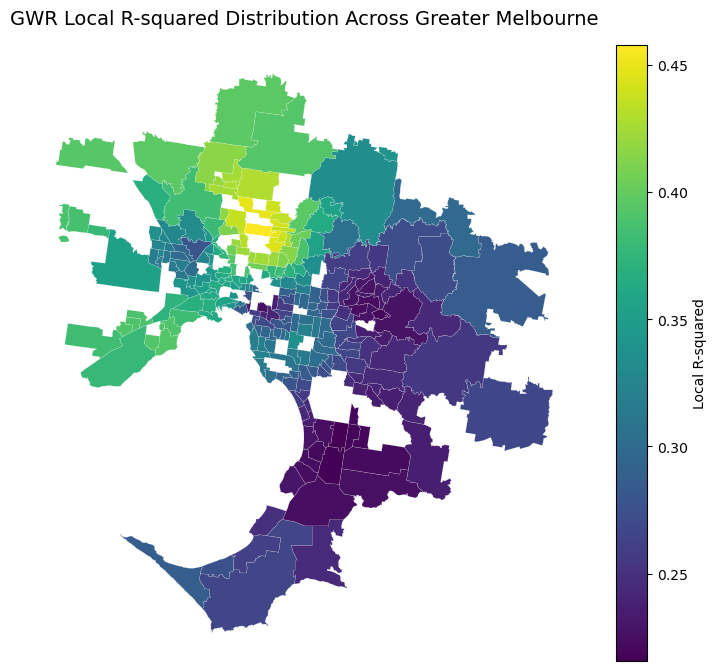

In [60]:
# Spatial distribution of local R-squared
fig, ax = plt.subplots(figsize=(10, 8))

q2.plot(
    column='gwr_local_R2', 
    cmap='viridis',        
    legend=True, 
    linewidth=0.1, 
    edgecolor='white',
    legend_kwds={'label': "Local R-squared"},
    ax=ax
)

ax.set_title("GWR Local R-squared Distribution Across Greater Melbourne", fontsize=14, pad=15)
ax.axis('off')

plt.show()

This local $R^2$ spatial distribution map confirms the strong spatial nonstationarity of the greening index's effect on mitigating the urban heat island effect (UHI). The model's explanatory power increases from a very low value in the southeast coastal area ($R^2$ around 0.23) towards the northwest, peaking in Melbourne's northwest suburbs and northern edge ($R^2$ > 0.45). This clear gradient pattern indicates that in the northwest region, far from the influence of oceanic air currents, tree density and green cover affect surface temperature, and the model can explain nearly half of the local heat island intensity variation. Conversely, in the southern and eastern coastal areas, the independent explanatory power of the greening index is reduced due to complex coastal climates (such as sea breeze modulation).

#### 6.4 Visualising Spatial Heterogeneity through GWR

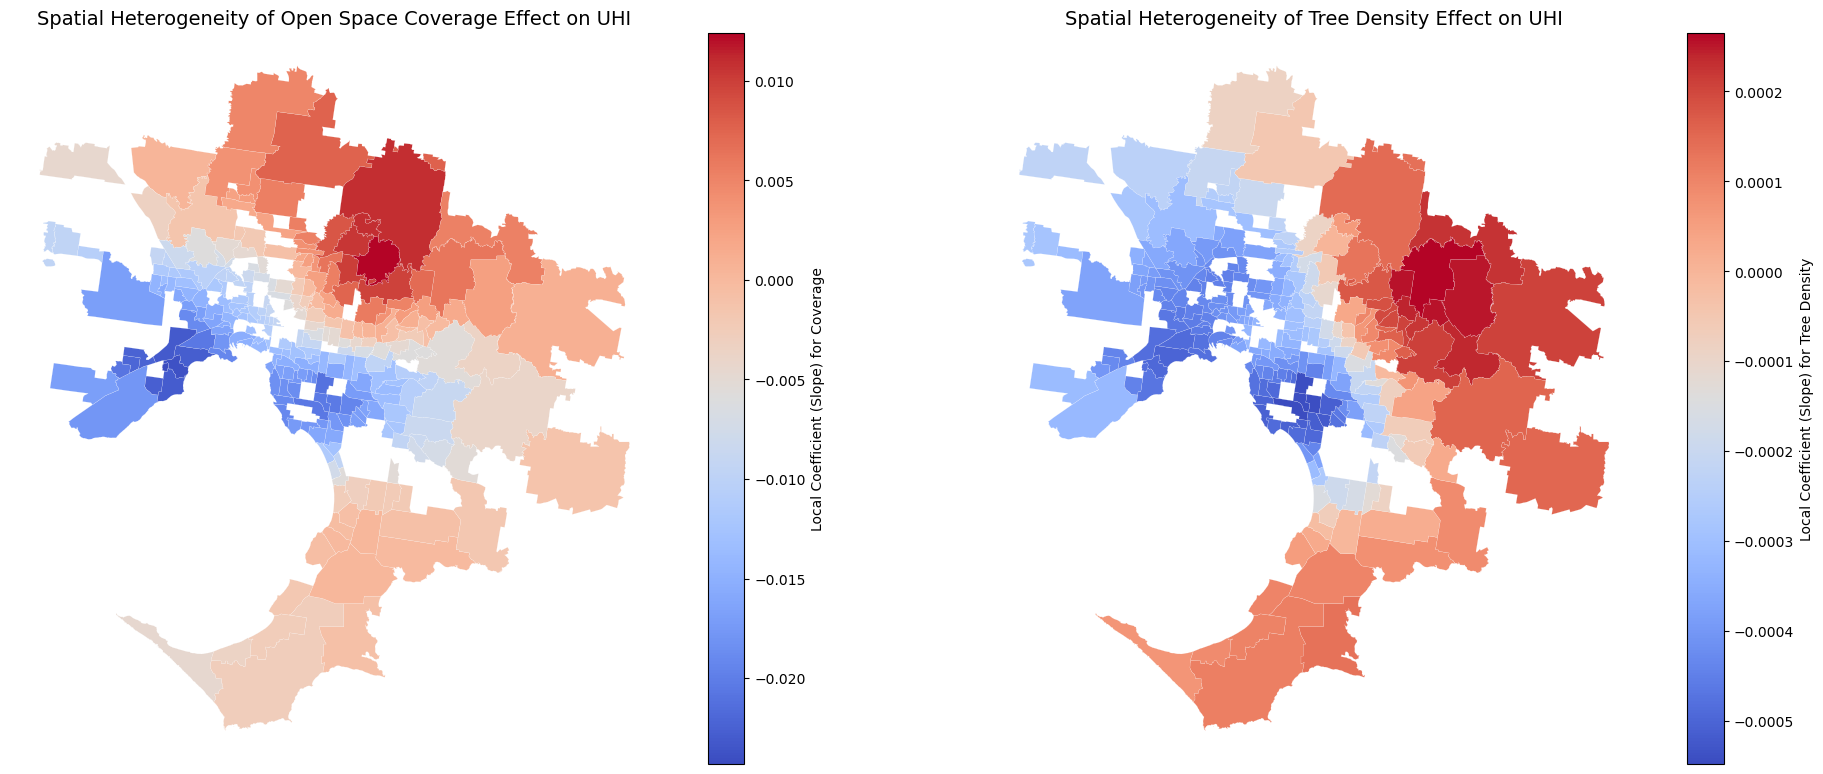

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Open Space Coverage
q2.plot(
    column='gwr_coef_coverage', 
    cmap='coolwarm',       
    legend=True, 
    linewidth=0.1, 
    edgecolor='white',
    ax=axes[0],
    legend_kwds={'label': "Local Coefficient (Slope) for Coverage"}
)
axes[0].set_title("Spatial Heterogeneity of Open Space Coverage Effect on UHI", fontsize=14)
axes[0].axis('off')

# Tree Density
q2.plot(
    column='gwr_coef_tree_density', 
    cmap='coolwarm', 
    legend=True, 
    linewidth=0.1, 
    edgecolor='white',
    ax=axes[1],
    legend_kwds={'label': "Local Coefficient (Slope) for Tree Density"}
)
axes[1].set_title("Spatial Heterogeneity of Tree Density Effect on UHI", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

* Spatial Heterogeneity of Open Space Coverage Effect on UHI

The impact of open space coverage on UHI exhibits a south-north spatial divide.

Positive values ​​in these localised areas mean that the higher the open space coverage, the higher the urban heat island intensity (UHI). This contradicts the conventional understanding that open spaces typically have a cooling effect. Possible reasons include the possibility that these open spaces might be bare soil, dry grass, or sports fields.

Negative values ​​indicate a consistent cooling effect: increased cover reduces the UHI, as seen in Melbourne's CBD and southwest coastal areas, suggesting that the construction of open green spaces in these regions yields significant cooling returns.

The coexistence of positive and negative coefficients indicates that the effect of open spaces is not unidirectional, but heavily dependent on local vegetation type, soil moisture, surrounding building density, and wind conditions.

* Spatial Heterogeneity of Tree Density Effect on UHI

The impact of tree density on UHI exhibits a clear east-west spatial divide.

Most areas show negative values, indicating that higher tree density corresponds to lower UHI—a consistent cooling effect. The dark blue areas are highly concentrated in Melbourne's west and the inner west. In the older eastern suburbs, possibly because the existing urban forests are already close to saturation, further increases in tree density have reduced their moderating effect on overall temperature.

Compared to open spaces, the coefficient for tree density is more stable in sign, almost entirely negative, indicating that the shading effect of trees dominates in most areas of Melbourne, and the cooling mechanism is stable.

### 7. Conclusion and Limitation

This section investigates the impact of open space coverage and tree density on the intensity of the urban heat island in the Melbourne metropolitan area. Traditional statistical methods did not reveal a significant global linear relationship, and spatial cluster analysis also indicated that the heat island effect is mainly driven by regional-scale processes. However, geographically weighted regression (GWR) further reveals that tree density exhibits a stable cooling effect across almost the entire study area (with consistently negative local coefficients), while the impact of open space coverage shows strong spatial heterogeneity: it can cool in some areas but may exacerbate the heat island effect in others.This suggests that the cooling effect of green infrastructure cannot be generalized. Tree density is a more reliable factor in mitigating the heat island, while the effect of open space depends on its specific type, humidity conditions, and surrounding environment. Therefore, heat island mitigation strategies in Melbourne should prioritize increasing tree density and involve specific analysis and design of open spaces.

**Limitations:**

1. The analysis was conducted at the SA2 level, which may have masked significant differences within suburban areas. When data is aggregated to relatively large spatial units, the localized cooling effects of parks and street trees may not be fully captured.

2. Open space coverage and tree density were used as a simplified indicator of the quality of green infrastructure. This dataset does not distinguish between different vegetation types, canopy density, tree height, irrigation conditions, or accessibility, all of which can influence cooling effects.

3. Residual analysis strongly suggests that future research should incorporate more environmental and urban variables, such as building density, industrial land, elevation, and distance from the coast.